In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [27]:
# ── 1. Read the catalog ───────────────────────────────────────────────────────
df = pd.read_csv("phot_full.csv")
print(df.head())
print(f"\n{len(df):,} sources loaded")
print(df.columns.tolist())

         x        y         ra        dec    F606W_0  e_F606W    F814W_0  \
0  1682.30   200.81  77.521967 -36.986563  18.358623    0.002  17.713787   
1   357.67  1450.11  77.542283 -36.974808  19.453087    0.003  17.799455   
2  3737.69  2163.09  77.497381 -36.962226  20.406725    0.009  18.618467   
3  2471.75  2627.76  77.515498 -36.958955  20.445087    0.004  19.013073   
4   385.61  2360.45  77.543517 -36.964833  20.544163    0.005  19.064502   

   e_F814W        V_0        I_0    E(B-V)   A_F606W   A_F814W       A_V  \
0    0.002  99.923643  99.957639  0.027483  0.068377  0.042213  0.075357   
1    0.002  99.923051  99.957314  0.027698  0.068913  0.042545  0.075949   
2    0.011  99.924857  99.958305  0.027040  0.067275  0.041533  0.074143   
3    0.003  99.924154  99.957919  0.027296  0.067913  0.041927  0.074846   
4    0.003  99.923135  99.957360  0.027668  0.068837  0.042498  0.075865   

        A_I  
0  0.041361  
1  0.041686  
2  0.040695  
3  0.041081  
4  0.041640  

5

**Things to note: It appears that the V_0 and I_0 columns are not filled in (all 99 values).  F606W_0 and F814W_0 seem to be extinction corrected already.**

In [3]:
# ── 2. Derived quantities ─────────────────────────────────────────────────────
df["color"] = df["F606W_0"] - df["F814W_0"]   # F606W - F814W color


In [4]:
# Central coordinate (median RA/Dec of the catalog)
ra0  = df["ra"].median()
dec0 = df["dec"].median()


In [5]:
# Delta RA in arcsec (cos(dec) projection), Delta Dec in arcsec
df["dRA"]  = (df["ra"]  - ra0) * np.cos(np.radians(dec0)) * 3600.0
df["dDec"] = (df["dec"] - dec0) * 3600.0


In [6]:
# ── 3. Quality filter ─────────────────────────────────────────────────────────
# Drop sources where F606W_0 < 90 and F814W < 90. and
# keep only well-measured stars (e.g. uncertainty < 0.5 mag in both bands)
good = (
    (df["F606W_0"] < 90) &
    (df["F814W_0"] < 90) &
    (df["e_F606W"] < 0.5) &
    (df["e_F814W"] < 0.5)
)
df_good = df[good].copy()
print(f"{len(df_good):,} sources pass quality cuts")


21,860 sources pass quality cuts


In [14]:
# ── Read the isochrone ─────────────────────────────────────────────────────
with open("padova_13pt5Gyr_0.00015.dat") as f:
    for line in f:
        if line.startswith("#"):
            header_line = line

col_names = header_line.lstrip("#").split()

iso = pd.read_csv(
    "padova_13pt5Gyr_0.00015.dat",
    comment="#",
    delim_whitespace=True,
    names=col_names
)

In [18]:
# ── Distance modulus for NGC 1827 at 9.3 Mpc ──────────────────────────────
d_mpc = 9.3
mu = 5 * np.log10(d_mpc * 1e6 / 10)          
print(f"Distance modulus (m-M) = {mu:.3f}")

iso["color_iso"]  = iso["F606W"] - iso["F814W"]
iso["F814W_app"]  = iso["F814W"] + mu

# Evolutionary stage labels
stage_map    = {1: "MS", 2: "SGB", 3: "RGB", 4: "HB", 7: "AGB", 8: "post-AGB"}
stage_colors = {1: "limegreen", 2: "yellow", 3: "red",
                4: "cyan",      7: "orange", 8: "magenta"}

Distance modulus (m-M) = 29.842


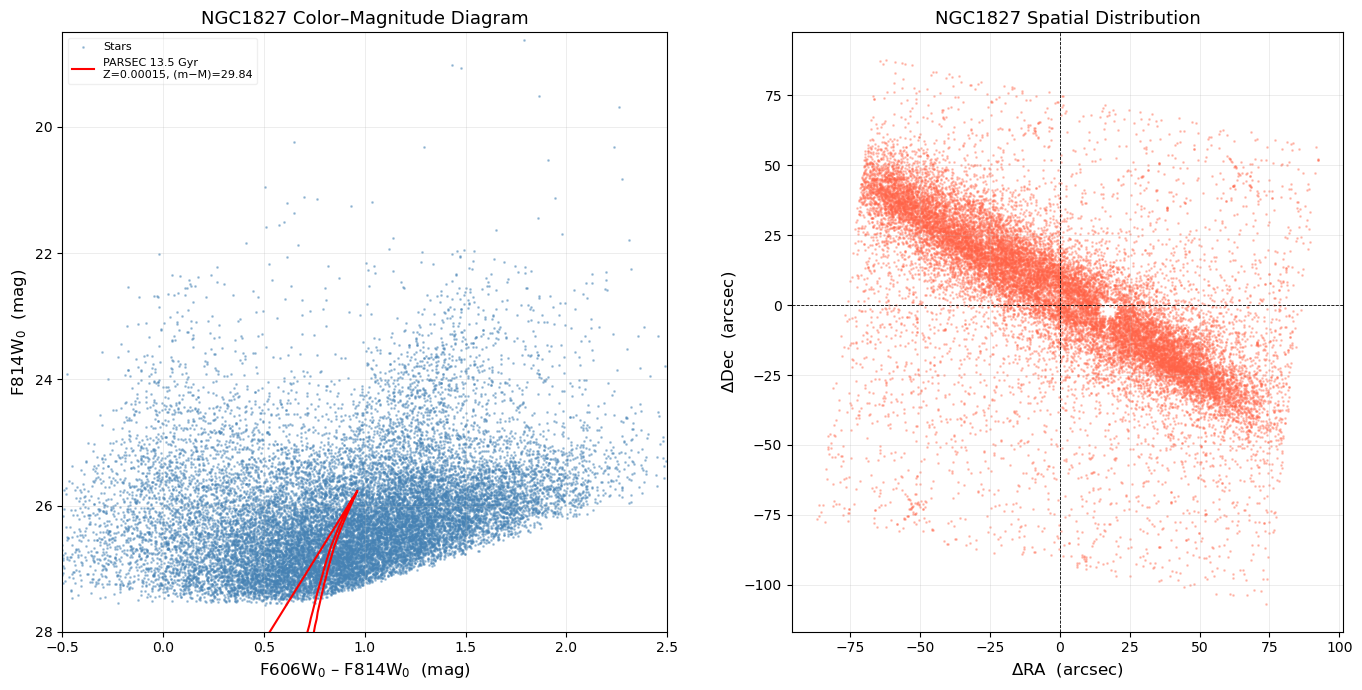

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# — CMD —
ax = axes[0]
ax.scatter(
    df_good["color"], df_good["F814W_0"],
    s=1, alpha=0.4, color="steelblue", rasterized=True, label="Stars"
)
ax.plot(
    iso["color_iso"], iso["F814W_app"],
    color="red", lw=1.5, zorder=5,
    label=f"PARSEC 13.5 Gyr\nZ=0.00015, (m−M)={mu:.2f}"
)
ax.set_xlabel("F606W$_0$ – F814W$_0$  (mag)", fontsize=12)
ax.set_ylabel("F814W$_0$  (mag)", fontsize=12)
ax.set_title("NGC1827 Color–Magnitude Diagram", fontsize=13)
ax.invert_yaxis()
ax.set_xlim(-0.5, 2.5)   # data-driven limits, same as before
ax.set_ylim(28.0, 18.5)   # data-driven limits, same as before
ax.legend(fontsize=8, loc="upper left", framealpha=0.3)
ax.grid(True, lw=0.4, alpha=0.4)

# — Spatial —
ax2 = axes[1]
ax2.scatter(
    df_good["dRA"], df_good["dDec"],
    s=1, alpha=0.3, color="tomato", rasterized=True
)
ax2.set_xlabel(r"$\Delta$RA  (arcsec)", fontsize=12)
ax2.set_ylabel(r"$\Delta$Dec  (arcsec)", fontsize=12)
ax2.set_title("NGC1827 Spatial Distribution", fontsize=13)
ax2.set_aspect("equal")
ax2.axhline(0, lw=0.6, color="k", ls="--")
ax2.axvline(0, lw=0.6, color="k", ls="--")
ax2.grid(True, lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("ngc1827_cmd_spatial.png", dpi=150)
plt.show()

In [ ]:
#RGB selection with more/less metallicities and then spatial distribution.